## Kaytoo | Model Evaluation & Validating Inference
### Bird Call Classification for New Zealand 
This notebook builds the inference code for Kaytoo, and evaluates its performance.  Methods that could be generalised to any kind of wildlife monitoring ML project are stored in the separate project WildPy.

## Basic Setup
Adjust the dictionary below for the overall notebook use case.  Note that I am processing different sound clips in parallel.  If using the GPU this results in multiple batches being sent to the GPU by different cores, so the number of cores needs to be reduced.  With 4Gb VRAM, max num_cores is 2.  This is still faster than CPU only with 6 cores.  

In [1]:
dummy_cell = 0  #Stops VSCode stalling sometimes

In [2]:
from pathlib import Path
project_root = str(Path().resolve().parent)
notebook_use = {
                'project_root': project_root,
                'experiment': '7',
                'bird_name_csv': 'data/experiments/exp_2/exp_2_deploy/exp_2_bird_map.csv',
                'folder_to_process': 'data/soundscapes/DOC_Tier1_2011',
                'model_choices': [0],
                'cpu_only': False,
                'num_cores': 1  #Can crank this up if using CPU only.
                }

## Imports

In [3]:
from pathlib import Path
env_path = Path(notebook_use['project_root']) / ".env"
print("Loading .env from:", env_path, "exists:", env_path.exists())

Loading .env from: /home/olly/Desktop/Kaytoo/.env exists: True


In [4]:

import os, sys
from dotenv import load_dotenv

load_dotenv(dotenv_path=Path(notebook_use['project_root']) / ".env")

for p in os.getenv("PYTHONPATH", "").split(os.pathsep):
    if p:
        print(f' Adding Python path: {p}')
        sys.path.append(str(Path(p).resolve()))

 Adding Python path: ../../wildpytools/src
 Adding Python path: ./src


In [5]:
import sys
print(sys.executable)
print(sys.path[:5])


/home/olly/miniconda3/envs/bird_audio_ml/bin/python
['/home/olly/Desktop/wildpytools/src', '/home/olly/Desktop/Kaytoo/src/src', '/home/olly/miniconda3/envs/bird_audio_ml/lib/python311.zip', '/home/olly/miniconda3/envs/bird_audio_ml/lib/python3.11', '/home/olly/miniconda3/envs/bird_audio_ml/lib/python3.11/lib-dynload']


In [6]:
#General Python
from IPython.display import Image, display
import yaml

#Local classes and functions
from bird_naming_utils import BirdNamer
from kaytoo_infer import  (inference,
                           get_images,
                           ImageDataset,
                           Models,
                           ModelParameters,
                           AudioParameters,
                           )

#Math & Plotting
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

#Machine Learning 
from sklearn.metrics import classification_report

#Torch and PyTorch specific
import torch

#Audio
import librosa

#wildpytools
from wildpytools.data import (remove_rare_classes,
                              convert_to_multiclass,
                              rename_predictions)
from wildpytools.metrics import (get_map_score,
                                 get_separation_score)
from wildpytools.plotting import (build_cf_matrix, 
                                  plot_continuous,
                                  plot_two_distributions,
                                  plot_scores_by_class,
                                  predictions_by_class)

print('Imports Complete')

Imports Complete


## Configuration Classes

In [7]:
class DefaultConfig:
    def __init__(self, bird_namer, options=None):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        if options:
            if options['cpu_only']:
                self.device = torch.device('cpu')
            if options['num_cores']:
                self.CORES = options['num_cores']
            else:
                self.CORES = 1
        self.classes = bird_namer.bird_list

In [8]:
class FilePaths:
    AUDIO_TYPES = {'.ogg','.wav', '.flac', '.mp3'}
    def __init__(self, options=None):
        self.root_folder = Path(options['project_root'])
        self.data_folder = self.root_folder / 'data'
        self.train_audios = self.data_folder / 'original_data/birdclef-2025/train_audio'
        self.experiment_results = self.data_folder / f"experiments/exp_{options['experiment']}/results"
        _temp_fldr = self.data_folder / f"experiments/exp_{options['experiment']}/temp"
        self.reloaded_val_preds_csv = self.experiment_results / f"exp_{options['experiment']}_reloaded_val_preds.csv"
        self.val_csv = self.experiment_results / 'val_labels.csv'
        self.bird_list_path = self.root_folder / options['bird_name_csv']
        self.soundscapes_folder = self.root_folder /options['folder_to_process']
        _moreporks_folder = self.data_folder / 'kiwi_morepork_sanity_check'
        self.morepork_kiwi = [path for path in _moreporks_folder.rglob('*') if path.suffix in self.AUDIO_TYPES]
        self.soundscapes = [path for path in self.soundscapes_folder.rglob('*') if path.suffix in self.AUDIO_TYPES]
        self.predictions_csv = self.soundscapes_folder / 'predictions.csv'
        self.learning_rate_monitor = self.experiment_results / f"exp_{options['experiment']}_training_metrics.jpg"
        self.train_metric_monitor = self.experiment_results / 'learning_rate.jpg'
        self.val_preds = self.experiment_results / 'val_pred_df.pkl'
        self.val_targs = self.experiment_results / 'val_target_df.pkl'
        self.val_images = [path for path in _temp_fldr.rglob('*.pt')]

## Helper Functions

In [9]:
class Colour:
    S = '\033[1m' + '\033[94m'
    E = '\033[0m'


def show_batch(img_ds, model_args, num_rows, num_cols):
    import numpy as np
    import matplotlib.pyplot as plt
    import librosa.display

    n_items = len(img_ds)
    if n_items == 0:
        raise ValueError("Dataset is empty.")

    # Create subplot grid
    fig, axes = plt.subplots(
        nrows=num_rows,
        ncols=num_cols,
        figsize=(15, 4 * num_rows),
        sharex=True,
        squeeze=False,   # always 2D
    )

    # Flatten axes to 1D list
    axes = axes.ravel()

    # Random indices (with replacement so it NEVER fails)
    img_inds = np.random.choice(n_items, num_rows * num_cols, replace=True)

    for index, ax in zip(img_inds, axes):
        # Dataset returns (img, label)
        img, _ = img_ds[index]
        shape = img.shape
        min_max = f"Min: {img.min():.2f}, Max: {img.max():.2f}"

        # Take the first channel
        red = img[0]

        # Normalise for display (safe div)
        mn, mx = red.min(), red.max()
        scaled = (red - mn) / (mx - mn + 1e-9)

        # Display spectrogram
        img_display = librosa.display.specshow(
            scaled,
            x_axis='time',
            y_axis='mel',
            sr=32000,
            n_fft=model_args['n_fft'] * model_args['image_shape'][0],
            hop_length=model_args['hop_length'],
            ax=ax
        )

        ax.set(title=f'Index {index}, shape={shape} ' + min_max)

        # Add colorbar for this subplot
        fig.colorbar(img_display, ax=ax, format="%+2.f dB")

    fig.tight_layout(pad=3.0)
    plt.show()



Common Helpers for WildPy

## Initialise

In [10]:
paths = FilePaths(options=notebook_use)
bird_map_df = pd.read_csv(paths.bird_list_path)
birdnames = BirdNamer(bird_map_df)

cfg = DefaultConfig(bird_namer=birdnames, 
                    options=notebook_use)
parameters = ModelParameters(options=notebook_use)

models = Models(config=cfg, 
                model_parameters=parameters)

model_args = models.args_list[0]
audio_cfg = AudioParameters(model_args)

print('The inference folder is:', paths.soundscapes_folder)
print(f'There are {len(models.args_list)} model(s) to be ensembled')
print(f'The model(s) will predict the following {len(models.ebirds)} classes (referring to their https://ebird.org code): \n')
for i in range(0, len(models.ebirds), 10):
    print(", ".join(models.ebirds[i:i + 10]))

Checking /home/olly/Desktop/Kaytoo/data/experiments/exp_7/exp_7_deploy for models...
The inference folder is: /home/olly/Desktop/Kaytoo/data/soundscapes/DOC_Tier1_2011
There are 1 model(s) to be ensembled
The model(s) will predict the following 87 classes (referring to their https://ebird.org code): 

ausbit1, ausmag2, auspip3, aussho1, baicra4, blbgul1, blfter1, blkswa, bluduc1, calqua
cangoo, caster1, charob1, chiger2, chukar, codpet1, comcha, commyn, compea, comred
coopet, dobplo1, dunnoc1, easros1, eurbla, eurgol, eurgre1, eursta, fernbi1, gretea1
grskiw1, gryger1, houspa, kea1, kelgul, kokako3, larus, liskiw1, litowl1, litpen1
lotkoe1, mallar3, maslap1, morepo2, motpet, nezbel1, nezfal1, nezfan1, nezkak1, nezpig2
nezrob2, nezrob3, nibkiw1, okbkiw1, oyster1, parake, parpet1, parshe1, piesti1, pipipi1
purswa6, rebgul1, redjun1, riflem1, rinphe1, sackin1, saddle2, shbcuc1, silver3, skylar
sobkiw2, soiwre1, sonthr1, spocra1, spocra2, swahar1, takahe3, tomtit1, tui1, weka1
welswa1, wet

In [11]:
paths.val_images

[PosixPath('/home/olly/Desktop/Kaytoo/data/experiments/exp_7/temp/val_images_0.pt'),
 PosixPath('/home/olly/Desktop/Kaytoo/data/experiments/exp_7/temp/val_images_3.pt'),
 PosixPath('/home/olly/Desktop/Kaytoo/data/experiments/exp_7/temp/val_images_2.pt'),
 PosixPath('/home/olly/Desktop/Kaytoo/data/experiments/exp_7/temp/val_images_1.pt'),
 PosixPath('/home/olly/Desktop/Kaytoo/data/experiments/exp_7/temp/val_images_4.pt')]

In [12]:
print('\nThe audio and network parameters for the first model are:')
for parameter, value in models.args_list[0].items():
    print(f'{parameter}: {value}')


The audio and network parameters for the first model are:
basename: timm/efficientnet_b2.ra_in1k
buffer_audio: 1
double_audio: True
hop_length: 500
image_shape: (2, 0.5)
image_time: 12
n_fft: 2048
n_mels: 192
spec_width: 768
use_deltas: True
pt_path: /home/olly/Desktop/Kaytoo/data/experiments/exp_7/exp_7_deploy/last.pt
pcen: False
ckpt_path: /home/olly/Desktop/Kaytoo/data/experiments/exp_7/temp/checkpoints/last.ckpt


In [13]:
def print_attrs(obj):
    for k, v in obj.__dict__.items():
        print(f"{k}: {v}")

print_attrs(audio_cfg)

IMAGE_SHAPE: (2, 0.5)
IMAGE_TIME: 12
SR: 32000
SPEC_WIDTH: 768
IMAGE_WIDTH: 384
DOUBLE_AUDIO: True
BUFFER_AUDIO: 1
N_MELS: 192
N_FFT: 2048
FMIN: 20
FMAX: 14000
HOP_LENGTH: 500
PCEN: False
USE_DELTAS: True


## Sanity Checks

Inspecting a soundscape from known Kiwi and morepork files: /home/olly/Desktop/Kaytoo/data/kiwi_morepork_sanity_check/morepo2/morepo2_33770_2.flac


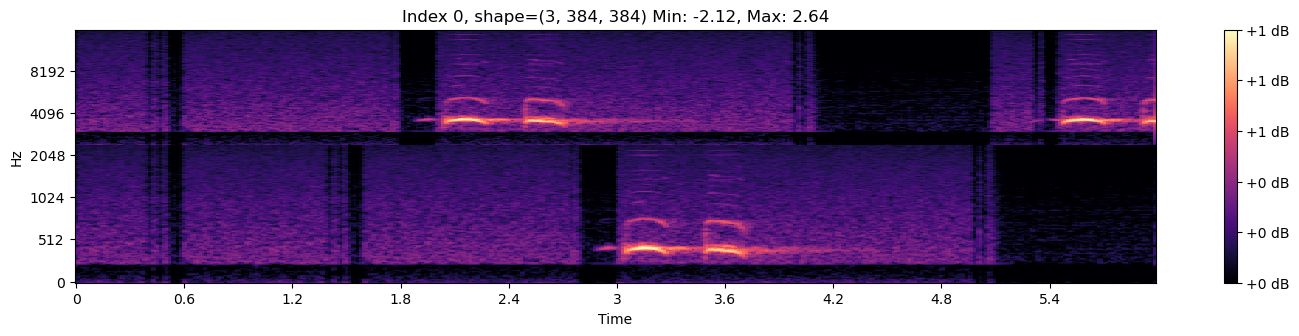

In [14]:
soundscape = random.choice(paths.morepork_kiwi)
print(f'Inspecting a soundscape from known Kiwi and morepork files: {soundscape}')
image_dict, num_extras = get_images(soundscape, model_args, audio_params=audio_cfg)
dataset = ImageDataset(image_dict,
                       audio_cfg.IMAGE_SHAPE,
                       audio_cfg.USE_DELTAS,
                       train=False)
show_batch(dataset, models.args_list[0], 1, 1)

In [15]:
pd.set_option("display.max_colwidth", None)
cols_to_view = ['row_id',  'nibkiw1', 'tomtit1', 'morepo2']
df = inference(paths.morepork_kiwi, models, 0, cores=cfg.CORES)
display(df[cols_to_view].head(10))

timm/efficientnet_b2.ra_in1k
Loading PyTorch from pt path: /home/olly/Desktop/Kaytoo/data/experiments/exp_7/exp_7_deploy/last.pt


Overall File List: 100%|██████████| 6/6 [00:01<00:00,  4.77it/s]


,row_id,nibkiw1,tomtit1,morepo2
0,/home/olly/Desktop/Kaytoo/data/kiwi_morepork_sanity_check/nibkiw1/nibkiw1_348749_2_5,0.235101,0.027230,0.351790
1,/home/olly/Desktop/Kaytoo/data/kiwi_morepork_sanity_check/nibkiw1/nibkiw1_348749_2_10,0.240729,0.019173,0.302793
2,/home/olly/Desktop/Kaytoo/data/kiwi_morepork_sanity_check/nibkiw1/nibkiw1_348749_1_5,0.398339,0.061368,0.363726
3,/home/olly/Desktop/Kaytoo/data/kiwi_morepork_sanity_check/nibkiw1/nibkiw1_348749_1_10,0.390522,0.046781,0.281195
4,/home/olly/Desktop/Kaytoo/data/kiwi_morepork_sanity_check/nibkiw1/nibkiw1_444283_1_5,0.678359,0.069204,0.233990
5,/home/olly/Desktop/Kaytoo/data/kiwi_morepork_sanity_check/nibkiw1/nibkiw1_444283_1_10,0.656433,0.103718,0.238025
6,/home/olly/Desktop/Kaytoo/data/kiwi_morepork_sanity_check/morepo2/morepo2_34725_5,0.205747,0.169347,0.747781
7,/home/olly/Desktop/Kaytoo/data/kiwi_morepork_sanity_check/morepo2/morepo2_33770_1_5,0.149423,0.107501,0.864786
8,/home/olly/Desktop/Kaytoo/data/kiwi_morepork_sanity_check/morepo2/morepo2_33770_1_10,0.130119,0.076139,0.879454
9,/home/olly/Desktop/Kaytoo/data/kiwi_morepork_sanity_check/morepo2/morepo2_33770_2_5,0.167907,0.106223,0.804311


Examination of predictions on the validation samples from the last training epoch

In [16]:
df_val_pred = pd.read_pickle(paths.val_preds)
df_val_true = pd.read_pickle(paths.val_targs)
df_val_pred.head(5)

,ausbit1,ausmag2,auspip3,aussho1,baicra4,blbgul1,blfter1,blkswa,bluduc1,calqua,...,tomtit1,tui1,weka1,welswa1,weta,whfter1,whiteh1,x00458,yellow2,yellow3
0,0.992159,0.004384,0.104442,0.319815,0.076279,0.023464,0.014829,0.030764,0.003370,0.000653,...,0.101696,0.030802,0.116600,0.009736,0.091812,0.035957,0.007160,0.051076,0.022838,0.008642
1,0.983755,0.005705,0.146277,0.212765,0.043880,0.012407,0.017444,0.013298,0.011757,0.001323,...,0.235686,0.038537,0.110806,0.011857,0.101441,0.029325,0.013548,0.027809,0.031775,0.015348
2,0.010950,0.025343,0.171676,0.001792,0.008217,0.000249,0.002752,0.004652,0.000007,0.000703,...,0.032930,0.024094,0.035680,0.002160,0.034837,0.000057,0.007978,0.018167,0.107546,0.001036
3,0.645111,0.005853,0.074978,0.021572,0.024712,0.011633,0.007731,0.003584,0.003575,0.000101,...,0.175356,0.077590,0.050824,0.021636,0.015762,0.003507,0.021666,0.013106,0.033067,0.014726
4,0.988504,0.000959,0.088512,0.130302,0.031489,0.003419,0.003689,0.004720,0.002031,0.000023,...,0.107986,0.010595,0.066729,0.004894,0.029949,0.005691,0.004430,0.011588,0.019278,0.015030


Now check that we got identical scores by re-loading the last saved checkpoint `last.ckpt` into the training model and stepping through the validation loader:

In [17]:
pd.set_option("display.max_colwidth", None)
cols_to_view = ['filename', 'ausbit1',	'ausmag2',	'auspip3',	'aussho1',	'baicra4']
last_preds_df = pd.read_csv(paths.reloaded_val_preds_csv)
last_preds_df[cols_to_view].head()

,filename,ausbit1,ausmag2,auspip3,aussho1,baicra4
0,Train_Tier1/train_audio/ausbit1/BN6_BIRD_121023_045716_001.flac,0.913744,0.031550,0.134712,0.366092,0.214468
1,Train_Tier1/train_audio/ausbit1/BN6_BIRP_121023_200001_003.flac,0.934078,0.025084,0.197802,0.242782,0.108254
2,Train_Tier1/train_audio/ausbit1/BT13_BIRP_161105_051211_001.flac,0.045120,0.063699,0.195213,0.077525,0.092853
3,Train_Tier1/train_audio/ausbit1/Y140_BIRA_161015_201457_001.flac,0.518903,0.042033,0.107612,0.073719,0.089092
4,Train_Tier1/train_audio/ausbit1/Y140_BIRA_161016_041229_001.flac,0.862085,0.025884,0.147812,0.176163,0.151968


Now let's step through those first three files with the inference code and ensure that's also very close (may not be identical since the deploy checkpoint is potentially not quite the same as the last checkpoint used above).

In [18]:
first_three_files = [paths.data_folder / fn for fn in  last_preds_df['filename'].to_list()][:5]
first_three_files

[PosixPath('/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/BN6_BIRD_121023_045716_001.flac'),
 PosixPath('/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/BN6_BIRP_121023_200001_003.flac'),
 PosixPath('/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/BT13_BIRP_161105_051211_001.flac'),
 PosixPath('/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/Y140_BIRA_161015_201457_001.flac'),
 PosixPath('/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/Y140_BIRA_161016_041229_001.flac')]

In [19]:
cols_to_view = ['row_id', 'ausbit1',	'ausmag2',	'auspip3',	'aussho1',	'baicra4', 'max_score']
first_three_df = inference(first_three_files, models, 0, cores=cfg.CORES, debug=True)

timm/efficientnet_b2.ra_in1k
Loading PyTorch from pt path: /home/olly/Desktop/Kaytoo/data/experiments/exp_7/exp_7_deploy/last.pt


Overall File List:  20%|██        | 1/5 [00:00<00:00,  6.92it/s]


The model parameters:
{'basename': 'timm/efficientnet_b2.ra_in1k', 'buffer_audio': 1, 'double_audio': True, 'hop_length': 500, 'image_shape': (2, 0.5), 'image_time': 12, 'n_fft': 2048, 'n_mels': 192, 'spec_width': 768, 'use_deltas': True, 'pt_path': PosixPath('/home/olly/Desktop/Kaytoo/data/experiments/exp_7/exp_7_deploy/last.pt'), 'pcen': False, 'ckpt_path': PosixPath('/home/olly/Desktop/Kaytoo/data/experiments/exp_7/temp/checkpoints/last.ckpt')}

The audio parameters
IMAGE_SHAPE: (2, 0.5)
IMAGE_TIME: 12
SR: 32000
SPEC_WIDTH: 768
IMAGE_WIDTH: 384
DOUBLE_AUDIO: True
BUFFER_AUDIO: 1
N_MELS: 192
N_FFT: 2048
FMIN: 20
FMAX: 14000
HOP_LENGTH: 500
PCEN: False
USE_DELTAS: True

The model parameters:
{'basename': 'timm/efficientnet_b2.ra_in1k', 'buffer_audio': 1, 'double_audio': True, 'hop_length': 500, 'image_shape': (2, 0.5), 'image_time': 12, 'n_fft': 2048, 'n_mels': 192, 'spec_width': 768, 'use_deltas': True, 'pt_path': PosixPath('/home/olly/Desktop/Kaytoo/data/experiments/exp_7/exp_7_dep

Overall File List:  60%|██████    | 3/5 [00:00<00:00, 10.58it/s]


The model parameters:
{'basename': 'timm/efficientnet_b2.ra_in1k', 'buffer_audio': 1, 'double_audio': True, 'hop_length': 500, 'image_shape': (2, 0.5), 'image_time': 12, 'n_fft': 2048, 'n_mels': 192, 'spec_width': 768, 'use_deltas': True, 'pt_path': PosixPath('/home/olly/Desktop/Kaytoo/data/experiments/exp_7/exp_7_deploy/last.pt'), 'pcen': False, 'ckpt_path': PosixPath('/home/olly/Desktop/Kaytoo/data/experiments/exp_7/temp/checkpoints/last.ckpt')}

The audio parameters
IMAGE_SHAPE: (2, 0.5)
IMAGE_TIME: 12
SR: 32000
SPEC_WIDTH: 768
IMAGE_WIDTH: 384
DOUBLE_AUDIO: True
BUFFER_AUDIO: 1
N_MELS: 192
N_FFT: 2048
FMIN: 20
FMAX: 14000
HOP_LENGTH: 500
PCEN: False
USE_DELTAS: True

The model parameters:
{'basename': 'timm/efficientnet_b2.ra_in1k', 'buffer_audio': 1, 'double_audio': True, 'hop_length': 500, 'image_shape': (2, 0.5), 'image_time': 12, 'n_fft': 2048, 'n_mels': 192, 'spec_width': 768, 'use_deltas': True, 'pt_path': PosixPath('/home/olly/Desktop/Kaytoo/data/experiments/exp_7/exp_7_dep

Overall File List: 100%|██████████| 5/5 [00:00<00:00, 11.38it/s]


In [20]:
first_three_df['max_score'] = first_three_df.iloc[:,2:].max(axis=1)
with pd.option_context('display.max_columns', None,
                       'display.width', None,
                       'display.max_colwidth', None):
    display(first_three_df[cols_to_view])

,row_id,ausbit1,ausmag2,auspip3,aussho1,baicra4,max_score
0,/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/BN6_BIRD_121023_045716_001_5,0.919545,0.035965,0.172296,0.392804,0.268646,0.919545
1,/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/BN6_BIRD_121023_045716_001_10,0.655906,0.064745,0.183062,0.303673,0.299451,0.655906
2,/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/BN6_BIRP_121023_200001_003_5,0.929576,0.023229,0.216329,0.249065,0.115949,0.929576
3,/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/BT13_BIRP_161105_051211_001_5,0.023130,0.063802,0.134795,0.015088,0.016900,0.886676
4,/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/Y140_BIRA_161015_201457_001_5,0.736276,0.058014,0.193871,0.175208,0.114602,0.736276
5,/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/Y140_BIRA_161016_041229_001_5,0.852772,0.042208,0.225833,0.168142,0.102423,0.852772


Now let's look at the spectrograms for these same images directly prior to sending to the model (TODO: double check this is really the case)

torch.Size([32, 3, 384, 384])
Min and max values for all channels:  -2.117904 2.64
Min and max values for red channel only:  -2.117904 2.2489083
The Shape of one spec is (3, 384, 384)


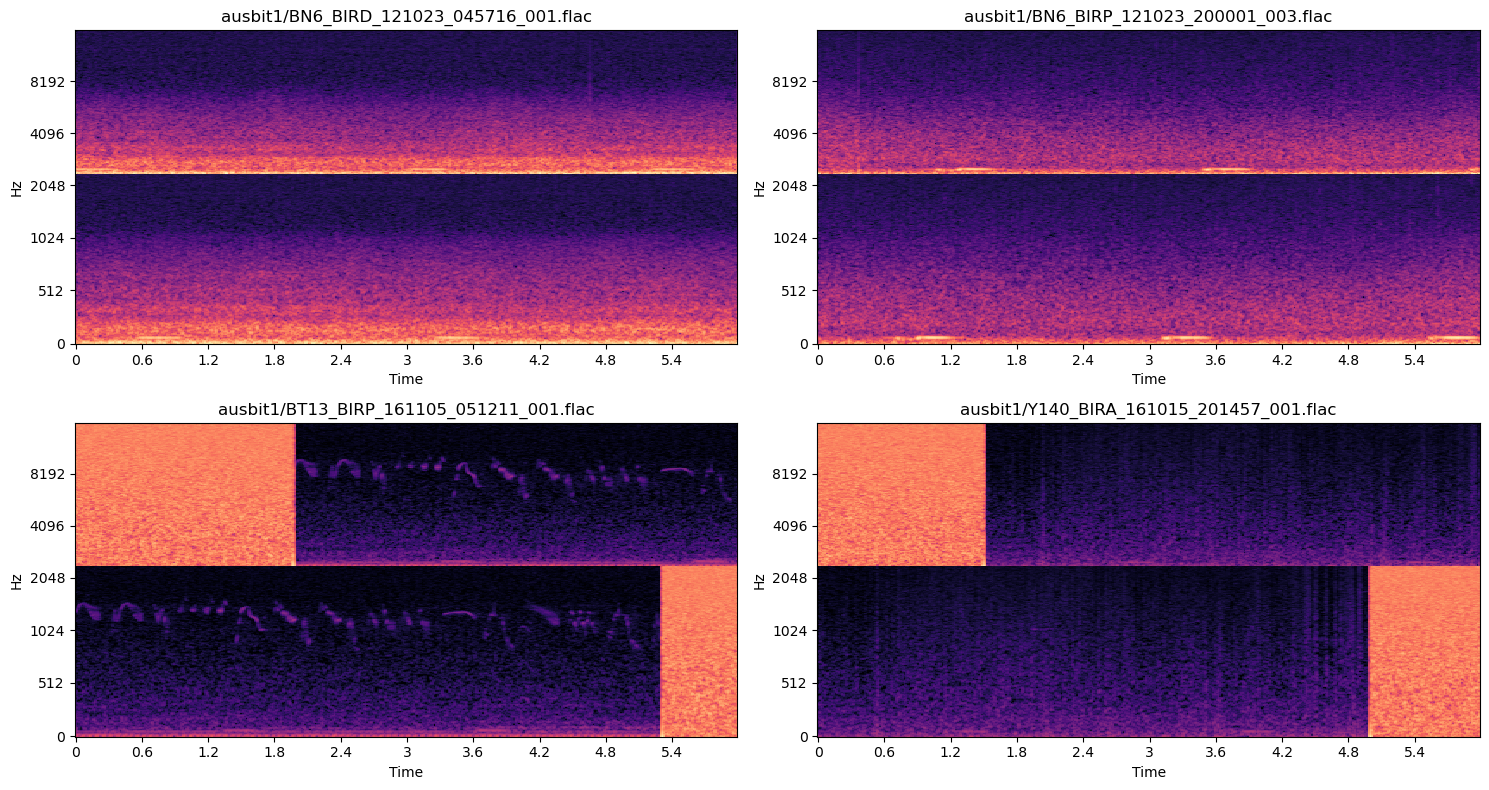

In [21]:
first_batch = torch.load(paths.val_images[0])
t = first_batch['images']   # (B, C, H, W)
print(t.shape)

# Select channel 0 only → (B, H, W)
#t = t[:, 2]

fig, axes = plt.subplots(2, 2, figsize=(15, 8), squeeze=False)
axes = axes.ravel()

for idx, ax in enumerate(axes):
    colour = t[idx].cpu().numpy()

    spec = colour[0]  #taking red channel
    if idx == 0:
        print('Min and max values for all channels: ', colour.min(), colour.max())
        print('Min and max values for red channel only: ', spec.min(), spec.max())
        print(f'The Shape of one spec is {colour.shape}')

    # Normalize for display
    mn, mx = spec.min(), spec.max()
    spec = (spec - mn) / (mx - mn + 1e-9)

    librosa.display.specshow(
        spec,
        x_axis="time",
        y_axis="mel",
        sr=32000,
        n_fft=model_args["n_fft"] * model_args["image_shape"][0],
        hop_length=model_args["hop_length"],
        ax=ax,
    )

    filepath = Path(first_batch["filenames"][idx])
    filename = filepath.parent.name + '/' + filepath.name 
    ax.set_title(filename)

plt.tight_layout()
plt.show()

In [22]:
first_three_files

[PosixPath('/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/BN6_BIRD_121023_045716_001.flac'),
 PosixPath('/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/BN6_BIRP_121023_200001_003.flac'),
 PosixPath('/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/BT13_BIRP_161105_051211_001.flac'),
 PosixPath('/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/Y140_BIRA_161015_201457_001.flac'),
 PosixPath('/home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/Y140_BIRA_161016_041229_001.flac')]

Inspecting a soundscape from known Australian Bittern files: /home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/BN6_BIRD_121023_045716_001.flac
(192, 768)
Min and max values for one spec from the dictionary gives min: 0.0, max: 1.0


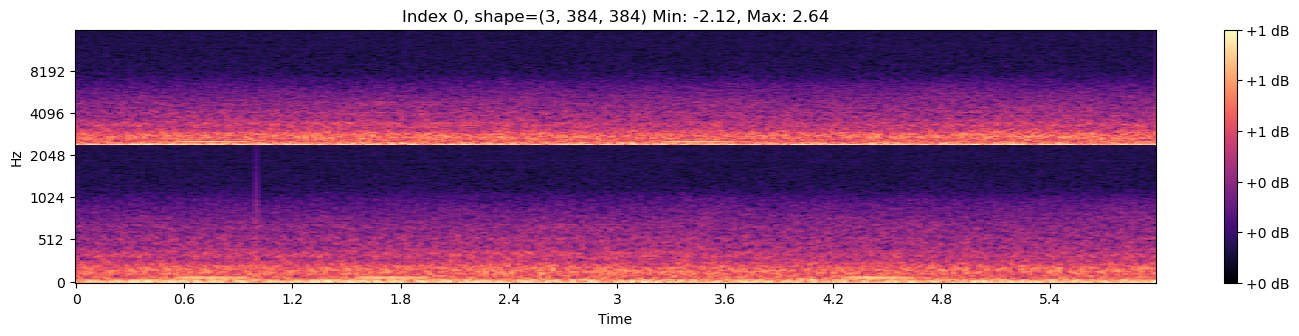

In [23]:
soundscape = first_three_files[0]
print(f'Inspecting a soundscape from known Australian Bittern files: {soundscape}')
image_dict, num_extras = get_images(soundscape, model_args, audio_params=audio_cfg)
print(image_dict[0].shape)
print(f'Min and max values for one spec from the dictionary gives min: {image_dict[0].min()}, max: {image_dict[0].max()}')   #Note that this is over all three channels, so expect -2.12 for Red, to +2.64 for Blue

#note that image dataset performs ImageNet Standardization
dataset = ImageDataset(image_dict,
                       audio_cfg.IMAGE_SHAPE,
                       audio_cfg.USE_DELTAS,
                       train=False)
show_batch(dataset, models.args_list[0], 1, 1)

Inspecting a soundscape the first three files in the validation split: /home/olly/Desktop/Kaytoo/data/Train_Tier1/train_audio/ausbit1/BT13_BIRP_161105_051211_001.flac
(192, 768)
Min and max values for one spec from the image dict:  0.0 1.0


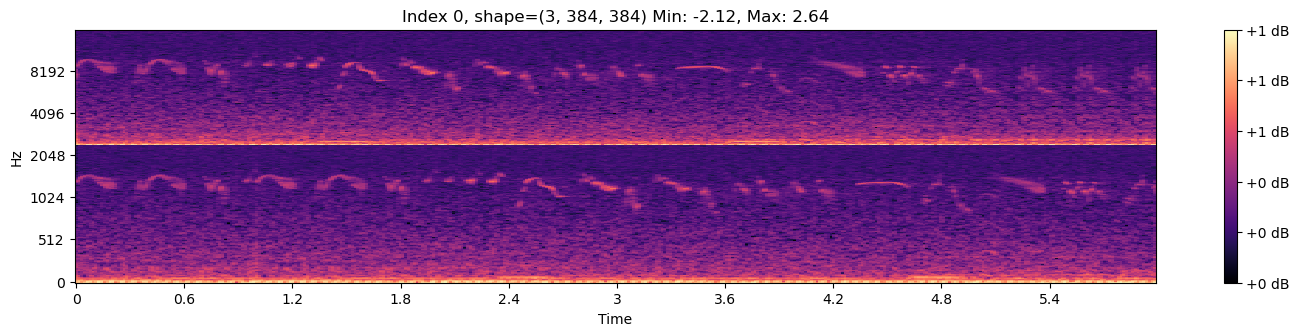

In [24]:
soundscape = first_three_files[2]
print(f'Inspecting a soundscape the first three files in the validation split: {soundscape}')
image_dict, num_extras = get_images(soundscape, model_args, audio_params=audio_cfg)
print(image_dict[0].shape)
print('Min and max values for one spec from the image dict: ', image_dict[0].min(), image_dict[0].max())
dataset = ImageDataset(image_dict,
                       audio_cfg.IMAGE_SHAPE,
                       audio_cfg.USE_DELTAS,
                       train=False)
show_batch(dataset, models.args_list[0], 1, 1)

## Analysis of Training Metrics

### Class Sizes and Distributions

First lets look at the classes and their sizes.

In [25]:
bird_map_df = bird_map_df.sort_values(by='TrainSamples').reset_index(drop=True)
bird_map_df.head(45)

,CommonName,eBird,ScientificName,ExtraName,TrainSamples,ValSamples
0,Common Diving-Petrel,codpet1,Pelecanoides urinatrix,Petrel,10,0.0
1,Spotted Crake,spocra1,Porzana porzana,Crake,10,0.0
2,Spotless Crake,spocra2,Zapornia tabuensis,Crake,10,0.0
3,Takahe,takahe3,Porphyrio hochstetteri,Takahe,10,0.0
4,Eastern Rosella,easros1,Platycercus eximius,Rosella,10,1.0
5,Chatham Robin,charob1,Petroica traversi,Robin,10,0.0
6,Caspian Tern,caster1,Hydroprogne caspia,Tern,10,0.0
7,Black Petrel,parpet1,Procellaria parkinsoni,Petrel,10,0.0
8,Domestic Chicken,redjun1,Gallus gallus,Chicken,10,0.0
9,Chukor,chukar,Alectoris chukar,Chukor,10,0.0


In [26]:
bird_map_df.tail(46)

,CommonName,eBird,ScientificName,ExtraName,TrainSamples,ValSamples
41,Little Spotted Kiwi,liskiw1,Apteryx owenii,Spotted Kiwi,91,10.0
42,Indian Myna,commyn,Acridotheres tristis,Myna,96,11.0
43,Southern Black-backed Gull,kelgul,Larus dominicanus,Gull,114,13.0
44,Red-billed Gull,rebgul1,Chroicocephalus novaehollandiae scopulinus,Gull,115,12.0
45,Starling,eursta,Sturnus vulgaris,Starling,126,14.0
46,Kereru,nezpig2,Hemiphaga novaeseelandiae,Kereru,142,16.0
47,Oystercatcher,oyster1,Haematopus sp,Oystercatcher,152,17.0
48,Paradise Shelduck,parshe1,Tadorna variegata,Shelduck,170,18.0
49,Canada Goose,cangoo,Branta canadensis,Goose,204,22.0
50,New Zealand Falcon,nezfal1,Falco novaeseelandiae,Falcon,211,23.0


In [27]:
rarest = bird_map_df[bird_map_df['TrainSamples'] <= 50]['eBird'].to_list()
print(rarest)

['codpet1', 'spocra1', 'spocra2', 'takahe3', 'easros1', 'charob1', 'caster1', 'parpet1', 'redjun1', 'chukar', 'saddle2', 'okbkiw1', 'motpet', 'gretea1', 'bluduc1', 'dobplo1', 'kokako3', 'blbgul1', 'chiger2', 'rinphe1', 'aussho1', 'welswa1', 'litowl1', 'whfter1', 'larus', 'compea', 'litpen1', 'mallar3', 'baicra4', 'houspa', 'blkswa', 'coopet', 'swahar1', 'blfter1', 'calqua', 'piesti1']


In [28]:
bird_map_df[bird_map_df['eBird'].isin(['parake', 'yefpar3', 'refpar4', 'oyster1', 'soioys1', 'varoys1'])]

,CommonName,eBird,ScientificName,ExtraName,TrainSamples,ValSamples
47,Oystercatcher,oyster1,Haematopus sp,Oystercatcher,152,17.0
71,Parakeet,parake,Psittaciformes sp.,Parakeet,2579,286.0


### Training Monitors

A custom learning rate scheduler was made for training, with a warmup period, decaying cycles and warm restarts (Only evident if training proceeded to more than one cycle).

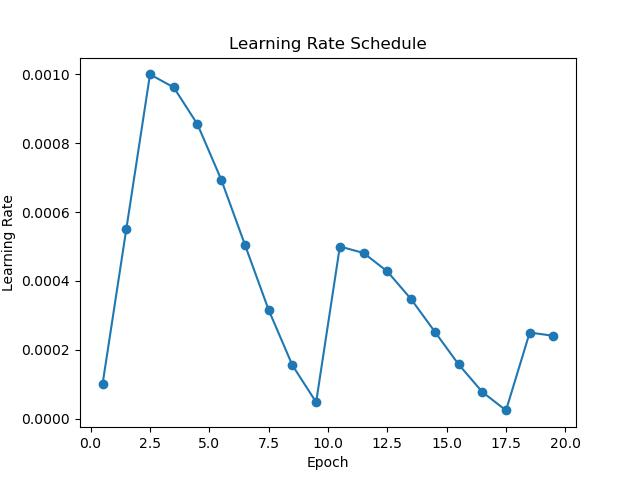

In [29]:
display(Image(filename=paths.train_metric_monitor))

Various performance parameters were monitored during training, on both the training samples and validation. Note that the relatively low scores for training is due to the heavy use of augmentation, and regularisation methods.  The validation samples by contrast were pre-processed in exactly the same way they would be prepared for inference.  Training began with heavy agumentation, and as it progressed the frequency and magnitude of the augmentation effects were reduced.

Plotted metrics:
- Train/Val Loss |  Focal Loss using binary cross entropy
- cmap5 | macro Average Precision score, but with all classes buffered by 5 true positives, to prevent excessive noise from the rare classes.
- LRAP  | Label Ranced Average Precision Score

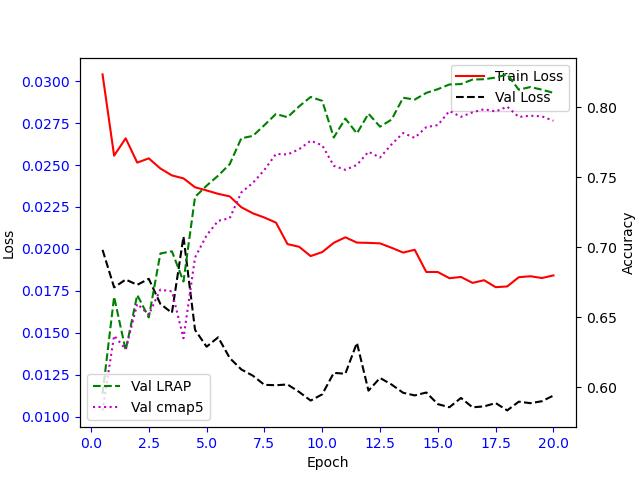

In [30]:
display(Image(filename=paths.learning_rate_monitor))

## Performance evaluation on the validation split
- The validation split consists of a random selection of 10% of the audio samples per class, but only for samples where the class had more than 10 samples, otherwise no samples were taken.
- For more than half the classes we don't have much data yet.  What data we have comes mostly from a small number of sites and is thus correlated between samples. For those two reasons there isn't much point trying to make a more sophisticated scheme to accurately predict real-life performance.
- For now I'm just going to make do by looking at the validation set, mainly for classes with more than 50 samples total (so > 5 samples in the validation split).  
- As more data comes to hand from the rarer classes it will become meaningful to develop a rigorous test method.
- From DOC's perspective there is a need to end up with some kind of hidden dataset, with no correlation to the training data.  Either by reserving some of this data by location, or ideally sourcing additional data, targeting the birds of most relevance to conservation goals.

In [31]:
eNames = list(df_val_pred.columns)
common_names  = birdnames.common_names(eNames)
short_names = birdnames.extra_names(eNames)


In [32]:
len(set(short_names))

67

Checking the predictions are sensible:

In [33]:
morepork_mask = df_val_true['morepo2'] == 1
df_val_pred[morepork_mask]['morepo2'].head()

2191    0.775162
2192    0.855777
2193    0.900931
2194    0.907591
2195    0.902381
Name: morepo2, dtype: float32

Let's switch to common names to make this easier to interpret.

In [34]:
rename_common_dict = {ename: birdnames.common_name(ename) for ename in df_val_true.columns}
df_val_true_common = rename_predictions(rename_common_dict, df_val_true)
df_val_pred_common = rename_predictions(rename_common_dict, df_val_pred)

In [35]:
morepork_mask = df_val_true_common['Morepork'] == 1
df_val_pred_common[morepork_mask]['Morepork'].head()

2191    0.775162
2192    0.855777
2193    0.900931
2194    0.907591
2195    0.902381
Name: Morepork, dtype: float32

In [36]:
if (df_val_pred.shape[0] == df_val_true.shape[0]) and (df_val_pred.shape[0] >=20):
    _, _ = plot_scores_by_class(df_val_true_common, df_val_pred_common, get_map_score, title = 'Average Precision Score by Species', min_samples=1)
    _, _ = plot_scores_by_class(df_val_true_common, df_val_pred_common, get_separation_score, title = "Cohen's D Score by Species",min_samples=10)
else:
    print(f'There were only {df_val_pred.shape[0]} rows in the predictions dataframe, too few for mAP scores')

The mean prediction value for true positives is: 0.62
The mean prediction value for true negatives is: 0.068


In [37]:
df_val_pred_common.head(3)

,Australasian Bittern,Australasian Harrier,Australasian Shoveler,Australian Magpie,Banded Dotterel,Bellbird,Black Petrel,Black Swan,Black-billed Gull,Black-fronted Tern,...,Starling,Takahe,Tomtit,Tree Weta,Tui,Weka,Welcome Swallow,White-fronted Tern,Whitehead,Yellowhammer
0,0.992159,0.010363,0.319815,0.004384,0.194592,0.106380,0.013721,0.030764,0.023464,0.014829,...,0.002009,0.039917,0.101696,0.091812,0.030802,0.116600,0.009736,0.035957,0.007160,0.022838
1,0.983755,0.007000,0.212765,0.005705,0.175025,0.161081,0.005162,0.013298,0.012407,0.017444,...,0.004804,0.024838,0.235686,0.101441,0.038537,0.110806,0.011857,0.029325,0.013548,0.031775
2,0.010950,0.004562,0.001792,0.025343,0.002840,0.027614,0.000271,0.004652,0.000249,0.002752,...,0.006440,0.000006,0.032930,0.034837,0.024094,0.035680,0.002160,0.000057,0.007978,0.107546


- The birds with more samples have much more consistent performance.  
- Anything with less than 5 validation samples (50 samples in total) was not plotted here, as the score would have little meaning.

How about the distribution of the predictions scores?  Let's look at this and decide on suitable thresholds for presence/absence

In [38]:
pred_vals = df_val_pred_common.values
targ_vals = df_val_true_common.values
tp_scores = (pred_vals * targ_vals).flatten()
tn_scores = (pred_vals * (1-targ_vals)).flatten()
tp_scores= tp_scores[tp_scores != 0]
tn_scores= tn_scores[tn_scores != 0]
print(Colour.S + 'The mean prediction value for true positives is: ' + Colour.E + f'{tp_scores.mean():.2}')
print(Colour.S + 'The mean prediction value for true negatives is: ' + Colour.E + f'{tn_scores.mean():.2}')

The mean prediction value for true positives is: 0.62
The mean prediction value for true negatives is: 0.041


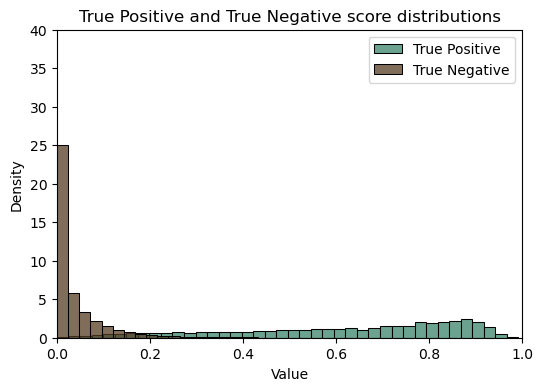

In [39]:
plot_two_distributions(tp_scores, tn_scores, label1='True Positive', label2='True Negative', bins=40, x_max=1, y_max=40)

Taking a closer look at the true positives

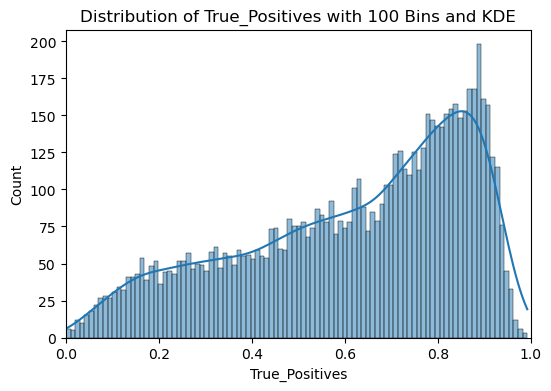

In [40]:
plot_continuous(pd.DataFrame(tp_scores, columns=['True_Positives']), 'True_Positives', x_min=0, x_max=1, bins=100)

Let's take a look at only samples with a single bird label, and plot true negatives and true positves for individual classes

In [41]:
df_combined = convert_to_multiclass(df_val_true_common, df_val_pred_common)
df_combined[df_combined['Targets']=='Morepork'][['Morepork']].head(3)

,Morepork
2191,0.775162
2192,0.855777
2193,0.900931


The mean for true positives is  0.820
The mean for true negatives is  0.132


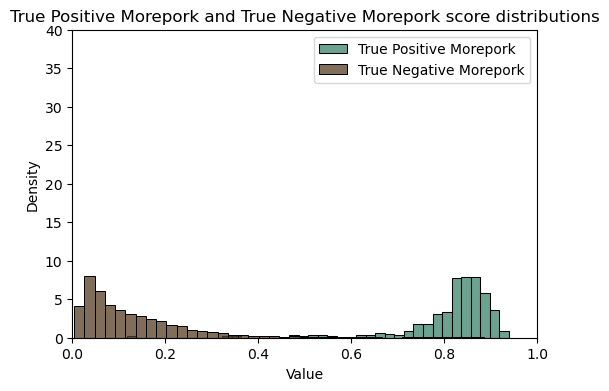

In [42]:
positive_mean, negative_mean = predictions_by_class('Morepork', df_combined, show_results=True)

The mean for true positives is  0.557
The mean for true negatives is  0.130


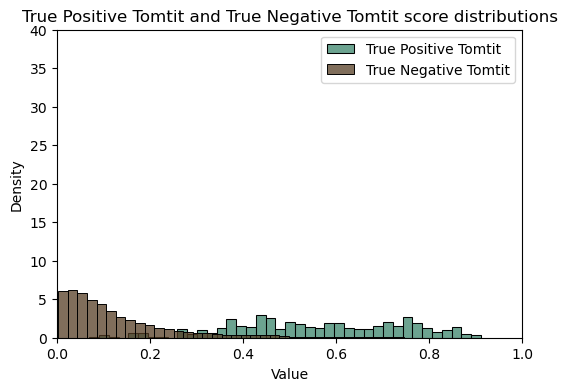

In [43]:
positive_mean, negative_mean = predictions_by_class('Tomtit', df_combined, show_results=True)

The mean for true positives is  0.568
The mean for true negatives is  0.159


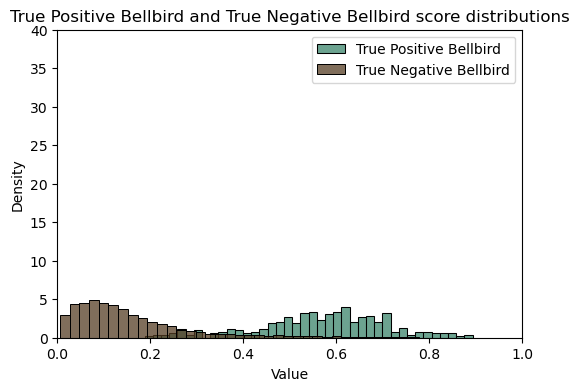

In [44]:
positive_mean, negative_mean = predictions_by_class('Bellbird', df_combined, show_results=True)

The mean for true positives is  0.571
The mean for true negatives is  0.087


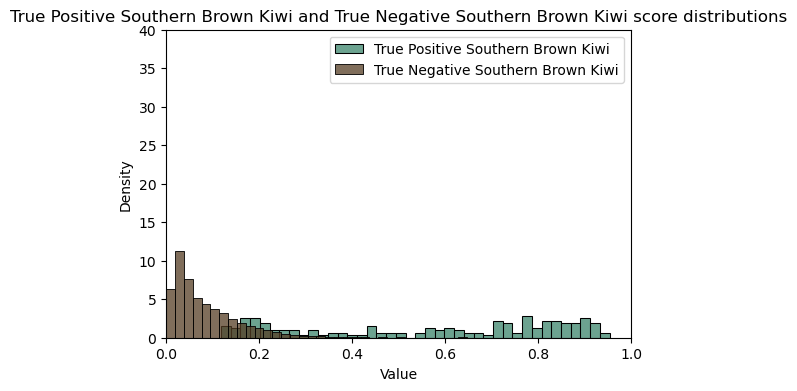

In [45]:
positive_mean, negative_mean = predictions_by_class('Southern Brown Kiwi', df_combined, show_results=True)	

The mean for true positives is  0.506
The mean for true negatives is  0.059


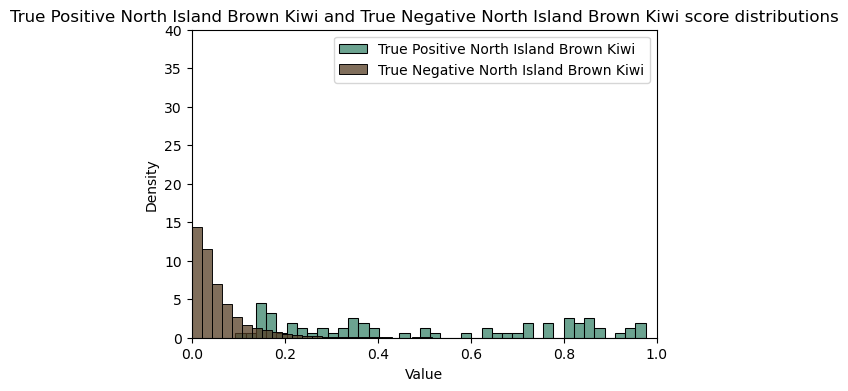

In [46]:
positive_mean, negative_mean = predictions_by_class('North Island Brown Kiwi', df_combined, show_results=True)

The mean for true positives is  0.613
The mean for true negatives is  0.061


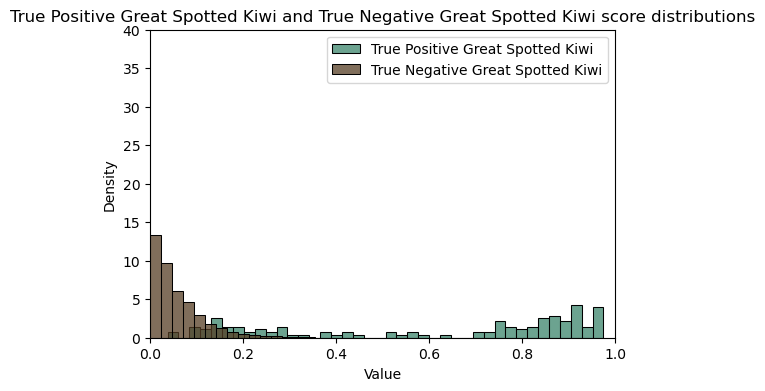

In [47]:
positive_mean, negative_mean = predictions_by_class('Great Spotted Kiwi', df_combined, show_results=True)

The mean for true positives is  0.579
The mean for true negatives is  0.028


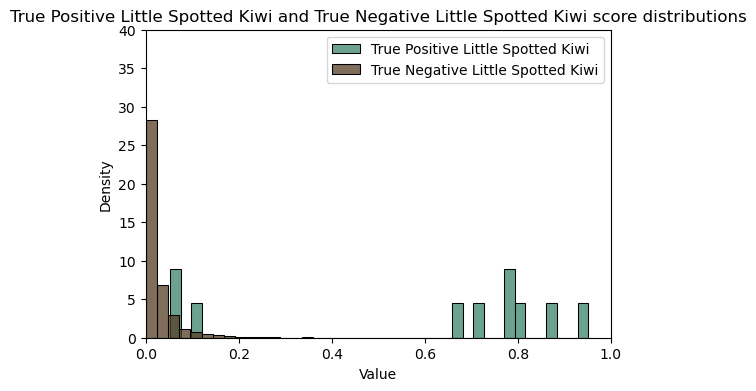

In [48]:
positive_mean, negative_mean = predictions_by_class('Little Spotted Kiwi', df_combined, show_results=True)

The mean for true positives is  0.767
The mean for true negatives is  0.033


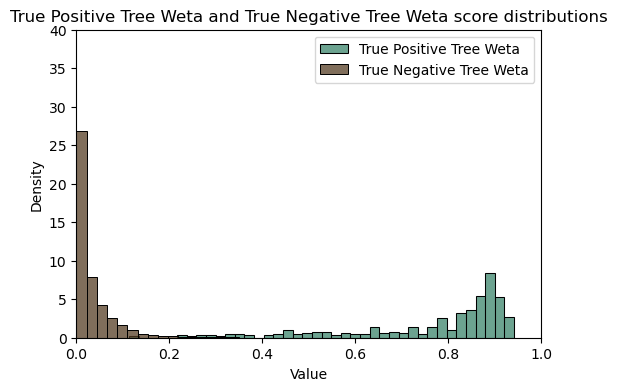

In [49]:
positive_mean, negative_mean = predictions_by_class('Tree Weta', df_combined, show_results=True)

A perfect classifier would have no overlap between these distributions.  In our case, the overlap is small. We would have virtually no false negatives with a threshold of 0.2, and a few false positives.   But in practice on soundscapes we already found that this underestimates the spread of the negatives. For now let's set a threshold of 0.3 and see what performance we get from some practical use metrics.

In [50]:
threshold = 0.3
pred_vals_binary = (pred_vals > threshold).astype(int)

In [51]:
targets = sorted(list(df_val_pred_common.columns))
scores_dict = classification_report(targ_vals, pred_vals_binary, target_names=targets, digits=2, output_dict=True, zero_division=1)
df_scores = pd.DataFrame.from_dict(scores_dict, orient='index')
df_scores_summary = df_scores.tail(4)
df_scores = df_scores.head(-4)
df_scores = df_scores.sort_values(by='support', ascending=False)
df_scores_summary

,precision,recall,f1-score,support
micro avg,0.455980,0.856262,0.595071,7458.0
macro avg,0.413862,0.641946,0.392767,7458.0
weighted avg,0.531531,0.856262,0.630250,7458.0
samples avg,0.597930,0.856262,0.669832,7458.0


In [52]:
pd.set_option('display.max_rows', 60)
df_scores.head()

,precision,recall,f1-score,support
Rifleman,0.540206,0.873333,0.667516,300.0
Fantail,0.673130,0.810000,0.735250,300.0
Chaffinch,0.345432,0.920000,0.502275,300.0
Silvereye,0.384078,0.916667,0.541339,300.0
Long-tailed Cuckoo,0.718519,0.970000,0.825532,300.0


Since we are treating this as a multi-label problem it isn't possible to make a single confusion matrix summarising all samples, since some samples have mutliple values for true.  We could produce individual $2 \times 2$ confusion matrices for each class, but this isn't especially interesting for current purposes.  Instead let's remove all the multi-label rows, and treat the remainder as multi-class, single-label.

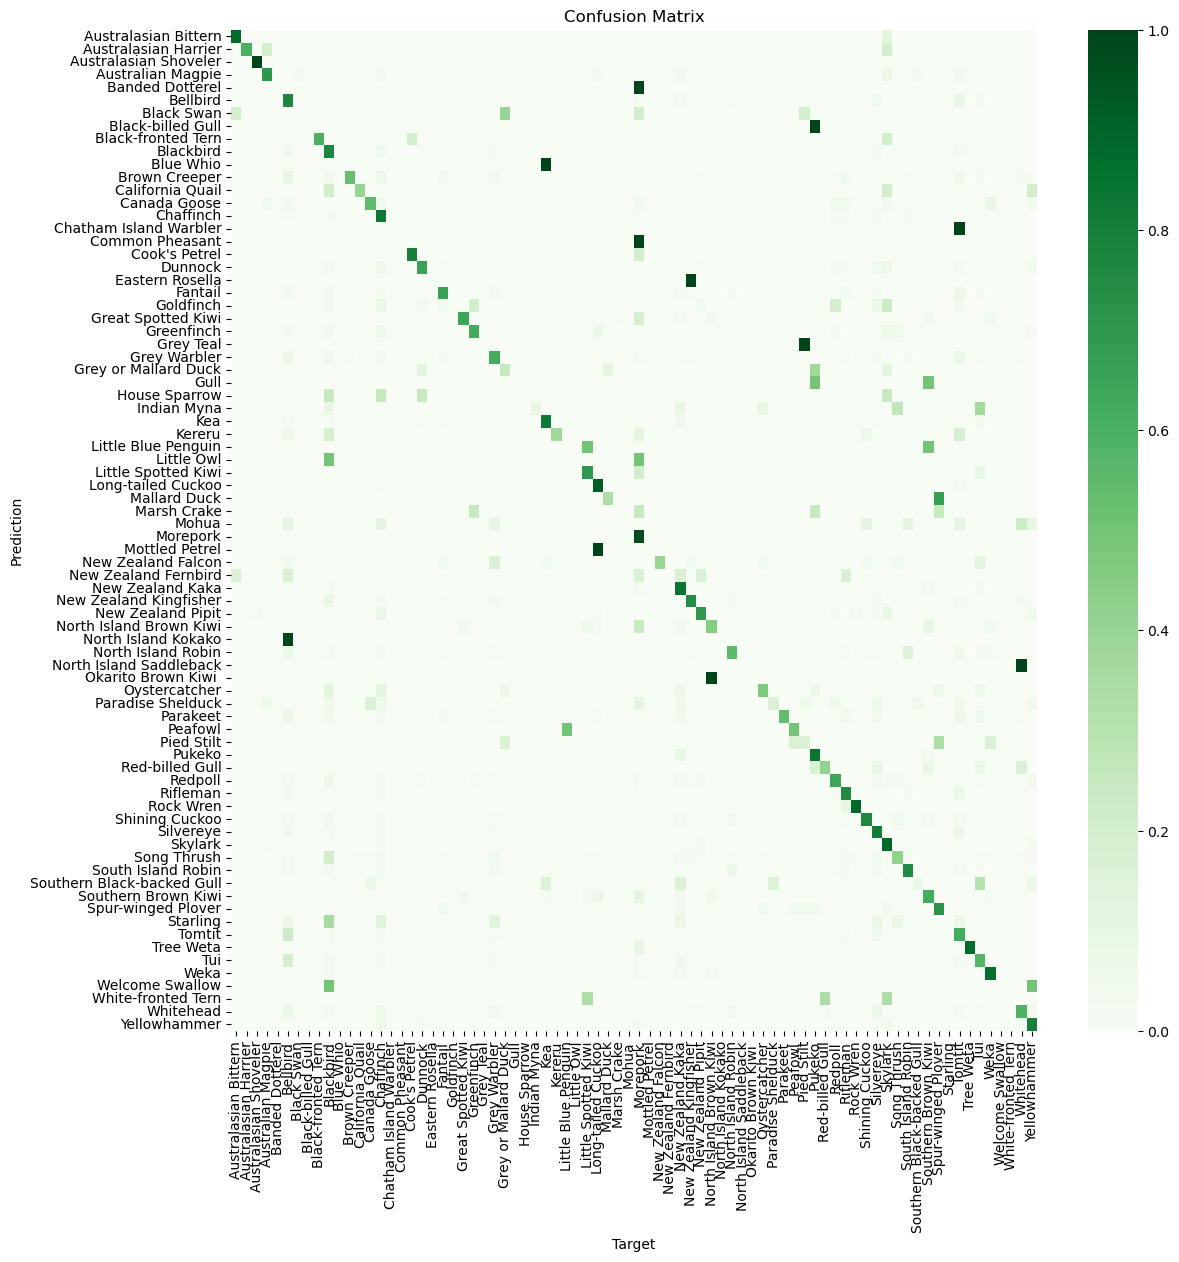

In [53]:
build_cf_matrix(df_val_true_common, df_val_pred_common, cf_fig_pth=None, cf_norm_pth=None)

## Performance with reduced classes

Let's re-plot with the typical class mergers made, and remove anything with less than 10 validation samples.

In [54]:
rename_short_dict = {ename: birdnames.extra_name(ename) for ename in df_val_true.columns}
df_val_true_short = rename_predictions(rename_short_dict, df_val_true,  merge_by = 'max')
df_val_pred_short = rename_predictions(rename_short_dict, df_val_pred,  merge_by = 'max')
df_val_pred_short.head(3)

,Bellbird,Bittern,Blackbird,Brown Kiwi,Chicken,Chukor,Crake,Creeper,Cuckoo,Dotterel,...,Thrush,Tomtit,Tui,Warbler,Weka,Weta,Whio,Whitehead,Wren,Yellowhammer
0,0.106380,0.992159,0.055043,0.147323,0.020760,0.103064,0.076279,0.024305,0.073121,0.194592,...,0.015079,0.101696,0.030802,0.031787,0.116600,0.091812,0.003370,0.007160,0.068018,0.022838
1,0.161081,0.983755,0.097172,0.159341,0.006884,0.088010,0.043880,0.050426,0.081312,0.175025,...,0.019931,0.235686,0.038537,0.058535,0.110806,0.101441,0.011757,0.013548,0.104057,0.031775
2,0.027614,0.010950,0.036514,0.057142,0.000261,0.002605,0.008217,0.025694,0.052888,0.002840,...,0.075559,0.032930,0.024094,0.046159,0.035680,0.034837,0.000007,0.007978,0.003536,0.107546


In [55]:
df_val_true_short, df_val_pred_short = remove_rare_classes(df_val_true_short, df_val_pred_short, 10)

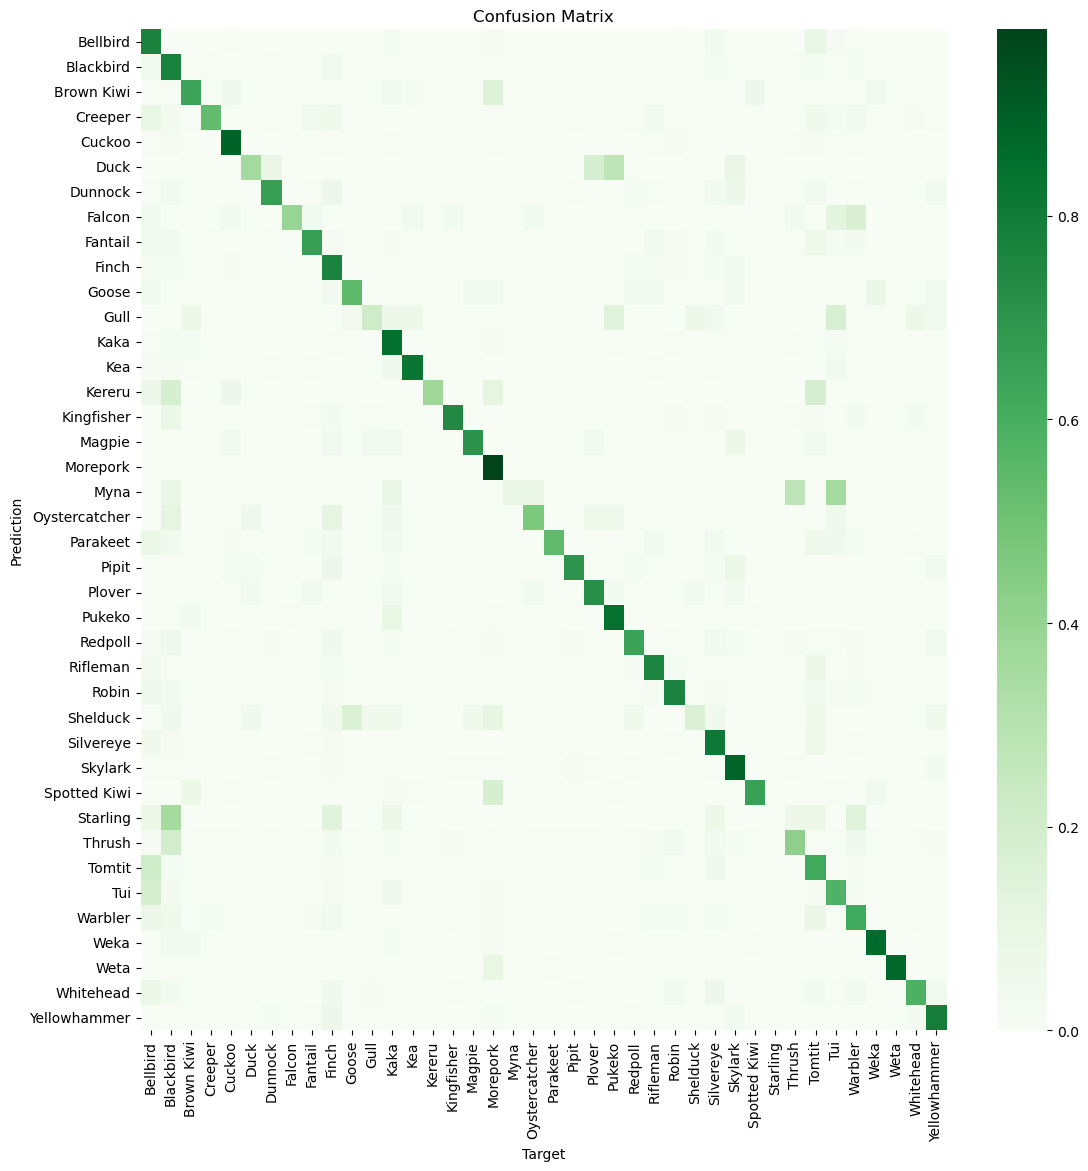

In [56]:
build_cf_matrix(df_val_true_short, df_val_pred_short, cf_fig_pth=None, cf_norm_pth=None)

The mean for true positives is  0.574
The mean for true negatives is  0.086


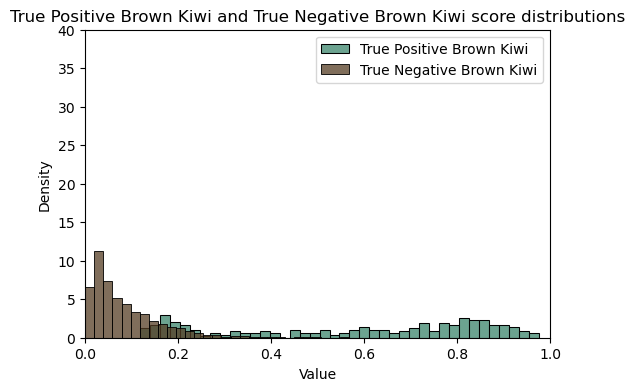

In [57]:
df_multi = convert_to_multiclass(df_val_true_short, df_val_pred_short)
positive_mean, negative_mean = predictions_by_class('Brown Kiwi', df_multi, show_results=True)	

The mean for true positives is  0.614
The mean for true negatives is  0.062


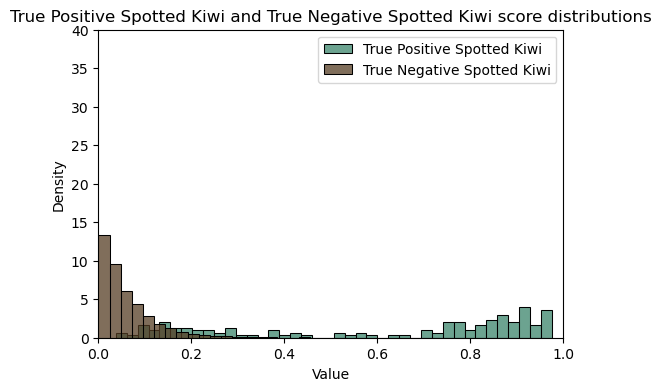

In [58]:
positive_mean, negative_mean = predictions_by_class('Spotted Kiwi', df_multi, show_results=True)	

These scores should be identical to the models saves in plain Pytorch Tensor .pt files

## Prediction on soundscapes in 5 second intervals

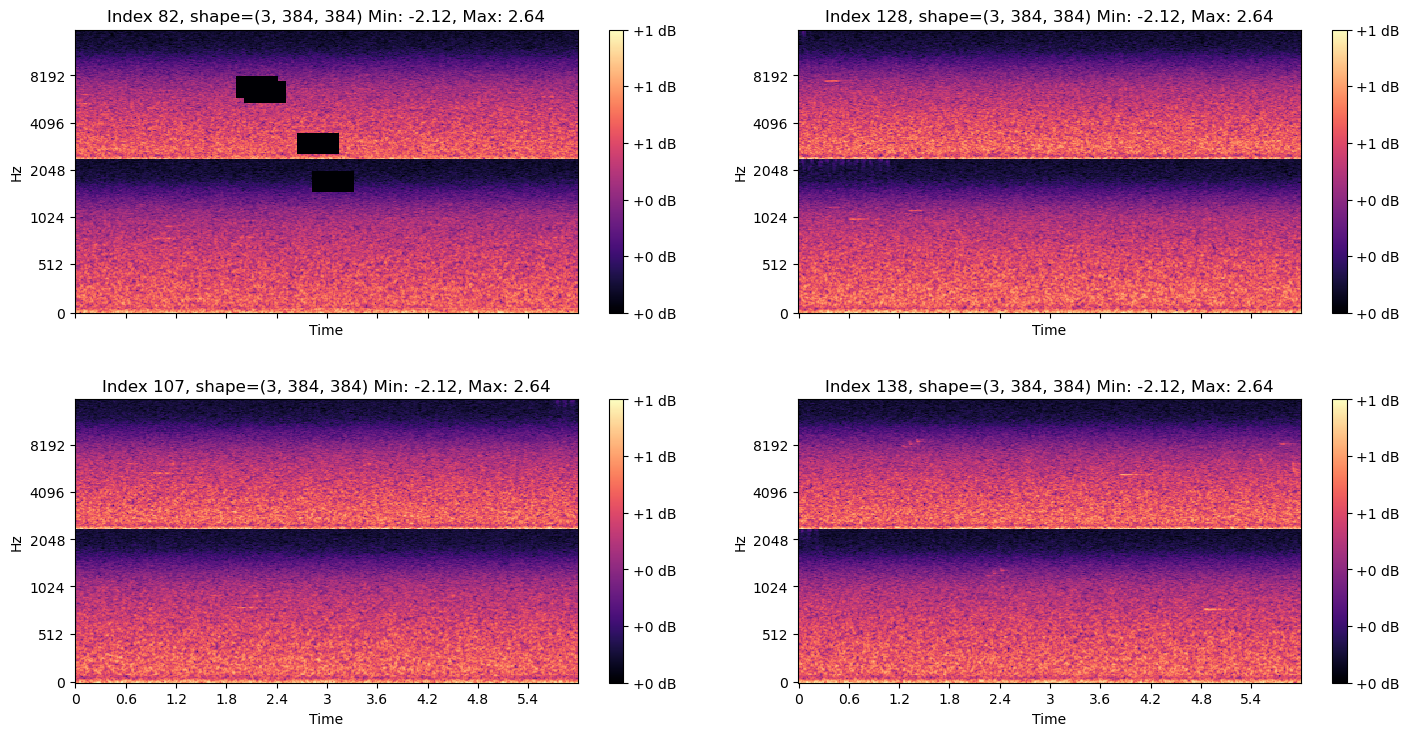

In [59]:
soundscape = random.choice(paths.soundscapes)
image_dict, num_extras = get_images(soundscape, models.args_list[0], audio_params=audio_cfg)
image_shape = models.args_list[0]['image_shape']
use_deltas = models.args_list[0]['use_deltas']
dataset = ImageDataset(image_dict, image_shape, use_deltas, train=True)
show_batch(dataset, models.args_list[0], 2,2)

In [60]:
print('\nThe first three recordings to be precessed are:')
for i in range(min(3, len(paths.soundscapes))):
    print(paths.soundscapes[i])


The first three recordings to be precessed are:
/home/olly/Desktop/Kaytoo/data/soundscapes/DOC_Tier1_2011/AS125_BIRD_120328_084429.wav
/home/olly/Desktop/Kaytoo/data/soundscapes/DOC_Tier1_2011/AS125_BIRM_120328_085925.wav
/home/olly/Desktop/Kaytoo/data/soundscapes/DOC_Tier1_2011/AS125_BIRP_120327_085925.wav


In [61]:
prediction_dfs = []
for idx in range(len(models.args_list)):
    df = inference(paths.soundscapes, models, idx, cores=cfg.CORES)
    prediction_dfs.append(df)

timm/efficientnet_b2.ra_in1k
Loading PyTorch from pt path: /home/olly/Desktop/Kaytoo/data/experiments/exp_7/exp_7_deploy/last.pt


Overall File List: 100%|██████████| 14/14 [01:44<00:00,  7.49s/it]


Average the various prediction dataframes

In [62]:
cols_to_view = ['row_id', 'ausbit1', 'ausmag2', 'auspip3', 'morepo2']  #'File_Path',
prediction_dfs[0][cols_to_view].head()

,row_id,ausbit1,ausmag2,auspip3,morepo2
0,/home/olly/Desktop/Kaytoo/data/soundscapes/DOC_Tier1_2011/AS125_BIRD_120328_084429_5,0.020203,0.024975,0.043942,0.129560
1,/home/olly/Desktop/Kaytoo/data/soundscapes/DOC_Tier1_2011/AS125_BIRD_120328_084429_10,0.020259,0.028274,0.030618,0.110806
2,/home/olly/Desktop/Kaytoo/data/soundscapes/DOC_Tier1_2011/AS125_BIRD_120328_084429_15,0.027056,0.042404,0.028020,0.146022
3,/home/olly/Desktop/Kaytoo/data/soundscapes/DOC_Tier1_2011/AS125_BIRD_120328_084429_20,0.035709,0.059637,0.102450,0.169311
4,/home/olly/Desktop/Kaytoo/data/soundscapes/DOC_Tier1_2011/AS125_BIRD_120328_084429_25,0.038246,0.073143,0.105910,0.173293


In [63]:
prediction_columns = prediction_dfs[0].columns[2:]
values_list = [df[prediction_columns].values for df in prediction_dfs]
average_vals = np.zeros_like(values_list[0])

for array in values_list:
    average_vals = average_vals + array 

average_vals = average_vals / len(values_list)
predictions = pd.DataFrame(data=average_vals, columns=prediction_columns)
predictions.insert(0, 'row_id', prediction_dfs[0]['row_id']) 

In [64]:
predictions.to_csv(paths.predictions_csv, index=False)

In [65]:
predictions.shape

(2520, 88)